In [1]:
import json
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Fetch data from Liiga API
url = "https://liiga.fi/api/v2/games?season=2025"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

with urllib.request.urlopen(req) as response:
    data = json.loads(response.read().decode())

df = pd.json_normalize(data)

# 2. Select key columns and create target
cols = [
    "id",
    "homeTeam.teamName",
    "awayTeam.teamName",
    "homeTeam.goals",
    "awayTeam.goals",
    "homeTeam.expectedGoals",
    "awayTeam.expectedGoals",
    "spectators",
    "finishedType",
]

df_liiga = df[cols].copy()
df_liiga.columns = [
    "id",
    "home_team",
    "away_team",
    "home_goals",
    "away_goals",
    "home_xg",
    "away_xg",
    "spectators",
    "finished_type",
]

# Create target variable
df_liiga["home_win"] = (
    df_liiga["home_goals"] > df_liiga["away_goals"]
).astype(int)

print(f"Dataset shape: {df_liiga.shape}")

Dataset shape: (614, 10)


In [2]:
# Check missing values in columns
print("Missing values per column:")
print(df_liiga.isnull().sum())

Missing values per column:
id                0
home_team         0
away_team         0
home_goals        0
away_goals        0
home_xg          32
away_xg          32
spectators        0
finished_type     0
home_win          0
dtype: int64


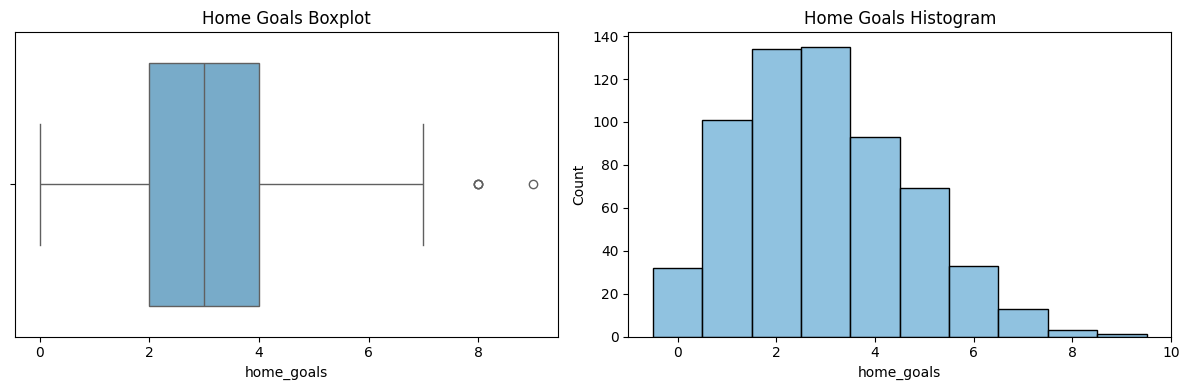

In [3]:
# Boxplot and Histogram for Home Goals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df_liiga["home_goals"], ax=axes[0], color="#6baed6")
axes[0].set_title("Home Goals Boxplot")

sns.histplot(
    df_liiga["home_goals"],
    discrete=True,
    ax=axes[1],
    color="#6baed6",
    edgecolor="black",
)
axes[1].set_title("Home Goals Histogram")

plt.tight_layout()
plt.show()

In [4]:
# Detect outliers using IQR for numerical metrics
num_cols = ["home_goals", "away_goals", "home_xg", "away_xg", "spectators"]

for col in num_cols:
    q1 = df_liiga[col].quantile(0.25)
    q3 = df_liiga[col].quantile(0.75)
    iqr = q3 - q1
    median = df_liiga[col].median()

    # Upper threshold: Median + 1.5 * IQR (as defined in Google/TikTok lab)
    threshold = median + 1.5 * iqr
    outliers = (df_liiga[col] > threshold).sum()

    print(
        f"Number of outliers in {col}: {outliers} (threshold = {threshold:.2f})"
    )

Number of outliers in home_goals: 17 (threshold = 6.00)
Number of outliers in away_goals: 11 (threshold = 6.00)
Number of outliers in home_xg: 15 (threshold = 4.63)
Number of outliers in away_xg: 21 (threshold = 4.12)
Number of outliers in spectators: 78 (threshold = 7211.50)


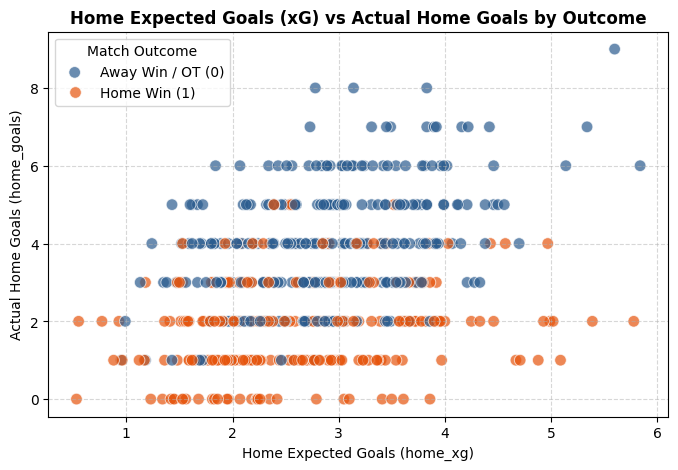

In [5]:
# Scatterplot: Expected Goals vs Actual Goals by Match Outcome
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_liiga,
    x="home_xg",
    y="home_goals",
    hue="home_win",
    palette={1: "#2b5c8f", 0: "#e6550d"},
    alpha=0.7,
    s=70,
)
plt.title(
    "Home Expected Goals (xG) vs Actual Home Goals by Outcome",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Home Expected Goals (home_xg)")
plt.ylabel("Actual Home Goals (home_goals)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Match Outcome", labels=["Away Win / OT (0)", "Home Win (1)"])
plt.savefig("liiga_xg_vs_goals_scatter.png", dpi=300, bbox_inches="tight")
plt.show()